# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 1/4

**NOMBRES:**

1. Elizabeth Correa Suarez

2. Juan Sebastian Ortega Muñoz

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*
 
---
**Derivada función Sigmoide:**
 
Formula:
 
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
 
**Derivada:**
 
Se aplica la regla del cociente $\left(\frac{u}{v}\right)' = \frac{u'v - uv'}{v^2}$, donde $u = 1$ y $v = 1 + e^{-z}$:
 
$$\sigma'(z) = \frac{0 \cdot (1 + e^{-z}) - 1 \cdot (-e^{-z})}{(1 + e^{-z})^2} = \frac{e^{-z}}{(1 + e^{-z})^2}$$
 
Se suma y se resta 1 en el numerador para factorizar
 
$$\sigma'(z) = \frac{(1 + e^{-z}) - 1}{(1 + e^{-z})^2} = \frac{1}{1+e^{-z}} - \frac{1}{(1+e^{-z})^2}$$
 
$$\sigma'(z) = \sigma(z) - \sigma(z)^2 = \sigma(z)\left(1 - \sigma(z)\right)$$
 
**Resultado:**
 
$$\boxed{\sigma'(z) = \sigma(z)\,(1 - \sigma(z))}$$
 
 
 
 
 
---
**Derivada función ReLU**
 
 
Formula:
 
$$\text{ReLU}(z) = \max(0, z) = \begin{cases} z & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}$$
 
**Derivada:**
 
Se calcula la derivada por casos, ya que esta función es a trozos
 
**Caso 1 :**
 
- cuando $z > 0$ :
 
    la función es $f(z) = z$
 
    $f'(z) = 1$
 
**Caso 2 :**
 
cuando $z < 0$:
 
la función es $f(z) = 0$, una constante:
 
$f'(z) = 0$
 
**Caso especial:**
 
$z = 0$: la derivada no existe, pero en la práctica se define como 0
 
**Resultado:**
 
$$\boxed{\text{ReLU}'(z) = \begin{cases} 1 & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}}$$
 
 
 
$$\text{ReLU}'(z) = \mathbb{1}[z > 0]$$
 
 
 
 
---
**Derivada función de costo: Entropia Cruzada**
 
 
Formula:
 
$$\mathcal{L}(Y, \hat{Y}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$
 
donde $y_i$ es la etiqueta real, $\hat{y}_i$ es la predicción y $m$ el número de ejemplos.
 
**Derivada:**
 
Se deriva respecto a $\hat{y}_i$ y $y_i$ es constante:
 
**Término 1:** $\frac{\partial}{\partial \hat{y}} \left[ -y \log(\hat{y}) \right] = -\frac{y}{\hat{y}}$
 
**Término 2:** $\frac{\partial}{\partial \hat{y}} \left[ -(1-y) \log(1 - \hat{y}) \right] = \frac{1-y}{1-\hat{y}}$
 
**Se suman los 2 términos:**
 
$$\frac{\partial \mathcal{L}}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$$
 
**Se simplifica** ya que tienen denominador común $\hat{y}(1-\hat{y})$):
 
$$\frac{\partial \mathcal{L}}{\partial \hat{y}} = \frac{-y(1-\hat{y}) + (1-y)\hat{y}}{\hat{y}(1-\hat{y})} = \frac{-y + \hat{y}}{\hat{y}(1-\hat{y})}$$
 
**Resultado:**
 
$$\boxed{\frac{\partial \mathcal{L}}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}}$$
 

## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [104]:
!pip install numpy matplotlib tensorflow scikit-learn

In [105]:
import numpy as np
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

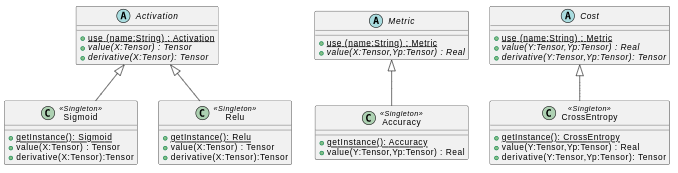

### MÉTRICA

In [106]:
class Metric(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica
  Representa la metrica de una red neuronal
  """
  def use(self, name: str) -> "Metric":
    """ obtiene metrica (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la metrica
    Returns:
      self (Metric): objeto metrica
    """
    if name.lower() == "accuracy":
      return Accuracy.getInstance()
    raise ValueError(f"Metrica no soportada: {name}")
 
  @abstractmethod
  def value(self, Y: np.ndarray, Yp:np.ndarray) -> float:
    """ computa el desempeño (accuracy) de la red (> 0.6 es 1)
    Args:
      Y (ndarray): valores de salidas esperadas (etiquetadas)
      Yp (ndarray): valores de salidas obtenidas
    Return:
      A (float): valor del desempeño
    """
    pass

In [107]:
# Documentar los métodos implementados
class Accuracy(Metric):
  """ Metrica de exactitud (acertados / totales). Implementa Metric
  """
  instance = None
 
  @staticmethod
  def getInstance():
    """ obtiene la única instancia de la métrica Accuracy
    Returns:
      Accuracy: instancia única de la métrica
    """
    if Accuracy.instance is None:
      Accuracy.instance = Accuracy()
    return Accuracy.instance
 
  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa el desempeño (accuracy) de la red (> 0.6 es 1)
    Args:
      Y (ndarray): valores de salidas esperadas
      Yp (ndarray): valores de salidas obtenidas
    Returns:
      A (float): valor del desempeño
    """
    Y = np.asarray(Y)
    Yp = np.asarray(Yp)
    Yp = (Yp > 0.6).astype(int)
    return float(np.mean(Y == Yp))

In [108]:
# Adicione los casos de prueba de los métodos implementados
 
acc1 = Accuracy.getInstance()
acc2 = Accuracy.getInstance()
 
assert acc1 is acc2
 
metric = acc1.use("accuracy")
assert metric is acc1
 
Y = np.array([[1, 0, 1, 0]])
Yp = np.array([[0.9, 0.1, 0.8, 0.2]])
assert acc1.value(Y, Yp) == 1.0
 
Y = np.array([[1, 0, 1, 1]])
Yp = np.array([[0.9, 0.1, 0.61, 0.2]])
assert acc1.value(Y, Yp) == 0.75
 
try:
    acc1.use("otra_metrica")
    assert False
except ValueError:
    pass

### COSTO

In [109]:
class Cost(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo
  Representa la función de costo o error de una red neuronal
  """
  
  @classmethod
  def use(cls, name: str) -> "Cost":
    """ obtiene función de costo (OBJ) a partir del nombre."""

    if not isinstance(name, str):
      raise TypeError("name debe ser str")

    name = name.strip().lower()
    if name in ("crossentropy", "cross_entropy", "entropia_cruzada", "entropía_cruzada"):
      return CrossEntropy.getInstance()

    raise ValueError(f"Función de costo no soportada: {name}")

  @abstractmethod
  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa la función de costo
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      S (float): valor de computo de la función de costo
    """
    pass

  @abstractmethod
  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de costo (gradiente) <elemento por elemento>
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de costo
    """
    pass

In [110]:
# Documentar los métodos implementados


class CrossEntropy(Cost):
  """ Función de costo Entropia Cruzada. Implementa Cost
  """
  instance = None

  def __init__(self, epsilon: float = 1e-12):
    """Inicializa la función con un epsilon para estabilidad numérica."""
    self.epsilon = float(epsilon)

  @classmethod
  def getInstance(cls) -> "CrossEntropy":
    """Devuelve una única instancia de CrossEntropy (Singleton)."""
    if cls.instance is None:
      cls.instance = cls()
    return cls.instance

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """Calcula la entropía cruzada binaria promedio."""
    Y = np.asarray(Y, dtype=float)
    Yp = np.asarray(Yp, dtype=float)
    if Y.shape != Yp.shape:
      raise ValueError(f"Y y Yp deben tener la misma forma. Recibido {Y.shape} vs {Yp.shape}")

    Yc = np.clip(Y, self.epsilon, 1.0 - self.epsilon)
    loss = -(Yp * np.log(Yc) + (1.0 - Yp) * np.log(1.0 - Yc))
    return float(np.mean(loss))

  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """Derivada de la entropía cruzada binaria promedio respecto a Y."""
    Y = np.asarray(Y, dtype=float)
    Yp = np.asarray(Yp, dtype=float)
    if Y.shape != Yp.shape:
      raise ValueError(f"Y y Yp deben tener la misma forma. Recibido {Y.shape} vs {Yp.shape}")

    Yc = np.clip(Y, self.epsilon, 1.0 - self.epsilon)
    grad = (-(Yp / Yc) + ((1.0 - Yp) / (1.0 - Yc))) / Y.size
    return grad

In [111]:
# Adicione los casos de prueba de los métodos implementados


Y_pred = np.array([0.9, 0.2, 0.7, 0.1])
Y_true = np.array([1.0, 0.0, 1.0, 0.0])

cost = CrossEntropy.getInstance()

# 1) Prueba de value
value = cost.value(Y_pred, Y_true)
expected_value = float(np.mean(-(Y_true * np.log(Y_pred) + (1 - Y_true) * np.log(1 - Y_pred))))
assert np.isclose(value, expected_value), f"value incorrecto: {value} != {expected_value}"

# 2) Prueba de derivative
grad = cost.derivative(Y_pred, Y_true)
expected_grad = (-(Y_true / Y_pred) + ((1 - Y_true) / (1 - Y_pred))) / Y_pred.size
assert np.allclose(grad, expected_grad), f"derivative incorrecto: {grad} != {expected_grad}"

# 3) Prueba de use en clase base
selected = Cost.use("cross_entropy")
assert isinstance(selected, CrossEntropy), "use no devolvió instancia CrossEntropy"

# 4) Prueba de Singleton
assert CrossEntropy.getInstance() is CrossEntropy.getInstance(), "CrossEntropy no cumple Singleton"
assert selected is CrossEntropy.getInstance(), "Cost.use no devuelve la instancia singleton"

print("Pruebas de Cost/CrossEntropy (Singleton) superadas")

Pruebas de Cost/CrossEntropy (Singleton) superadas


### ACTIVACION

In [112]:
class Activation(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave de cualquier función de activación
  Representa la función de activación de cualquier neurona en la red neuronal
  """
  @classmethod
  def use(cls, name: str) -> "Activation":
    """Obtiene función de activación (OBJ) a partir del nombre."""
    if not isinstance(name, str):
      raise TypeError("name debe ser str")

    name = name.strip().lower()
    if name in ("sigmoid", "sigmoide"):
      return Sigmoid.getInstance()
    if name in ("relu",):
      return Relu.getInstance()

    raise ValueError(f"Función de activación no soportada: {name}")

  @abstractmethod
  def value(self, X: np.ndarray) -> np.ndarray:
    """ computa la función de activación <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      S (ndarray): valores de computo de la función de activación
    """
    pass

  @abstractmethod
  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de activación (gradiente) <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de activación
    """
    pass

In [113]:
# Documentar los métodos implementados


class Sigmoid(Activation):
  """ Función de activación sigmoide. Implementa Activación
  """
  instance = None

  @classmethod
  def getInstance(cls) -> "Sigmoid":
    """Devuelve una única instancia de Sigmoid (Singleton)."""
    if cls.instance is None:
      cls.instance = cls()
    return cls.instance

  def value(self, X: np.ndarray) -> np.ndarray:
    """Aplica sigmoide elemento por elemento."""
    X = np.asarray(X, dtype=float)
    return 1.0 / (1.0 + np.exp(-X))

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """Derivada de la sigmoide elemento por elemento."""
    S = self.value(X)
    return S * (1.0 - S)

In [114]:
# Documentar los métodos implementados


class Relu(Activation):
  """ Función de activación RELU. Implementa Activación
  """
  _instance = None

  @classmethod
  def getInstance(cls) -> "Relu":
    """Devuelve una única instancia de Relu (Singleton)."""
    if cls._instance is None:
      cls._instance = cls()
    return cls._instance

  def value(self, X: np.ndarray) -> np.ndarray:
    """Aplica ReLU elemento por elemento."""
    X = np.asarray(X, dtype=float)
    return np.maximum(0.0, X)

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """Derivada de ReLU elemento por elemento."""
    X = np.asarray(X, dtype=float)
    return np.where(X > 0.0, 1.0, 0.0)

In [115]:
# Adicione los casos de prueba de los métodos implementados


X = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])

sig = Sigmoid.getInstance()
relu = Relu.getInstance()

# 1) Sigmoid value
sig_val = sig.value(X)
sig_expected = 1.0 / (1.0 + np.exp(-X))
assert np.allclose(sig_val, sig_expected), f"Sigmoid.value incorrecto: {sig_val} != {sig_expected}"

# 2) Sigmoid derivative
sig_der = sig.derivative(X)
sig_der_expected = sig_expected * (1.0 - sig_expected)
assert np.allclose(sig_der, sig_der_expected), f"Sigmoid.derivative incorrecto: {sig_der} != {sig_der_expected}"

# 3) Relu value
relu_val = relu.value(X)
relu_expected = np.maximum(0.0, X)
assert np.allclose(relu_val, relu_expected), f"Relu.value incorrecto: {relu_val} != {relu_expected}"

# 4) Relu derivative
relu_der = relu.derivative(X)
relu_der_expected = np.where(X > 0.0, 1.0, 0.0)
assert np.allclose(relu_der, relu_der_expected), f"Relu.derivative incorrecto: {relu_der} != {relu_der_expected}"

# 5) Prueba de use en clase base
a1 = Activation.use("sigmoid")
a2 = Activation.use("relu")
assert isinstance(a1, Sigmoid), "Activation.use('sigmoid') no devolvió Sigmoid"
assert isinstance(a2, Relu), "Activation.use('relu') no devolvió Relu"

# 6) Prueba de Singleton (siempre misma instancia)
assert Sigmoid.getInstance() is Sigmoid.getInstance(), "Sigmoid no cumple Singleton"
assert Relu.getInstance() is Relu.getInstance(), "Relu no cumple Singleton"
assert a1 is Sigmoid.getInstance(), "use('sigmoid') no devuelve la instancia singleton"
assert a2 is Relu.getInstance(), "use('relu') no devuelve la instancia singleton"

## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

#### Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**

En cada capa, la salida lineal es:

$$Z = W \cdot A_{prev} + b$$

Por regla de la cadena:

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial W}$$

**Paso 1** : derivada de $Z$ respecto a $W$:

$$\frac{\partial Z}{\partial W} = A_{prev}$$

**Paso 2** : llamamos $\delta$ al gradiente que llega desde la capa siguiente:

$$\delta = \frac{\partial L}{\partial Z}$$

**Paso 3** : unimos los dos términos:

$$\frac{\partial L}{\partial W} = \delta \cdot A_{prev}^T$$

**Paso 4** : promediamos sobre los $m$ ejemplos:

$$\boxed{dW = \frac{1}{m} \cdot \delta \cdot A_{prev}^T}$$

---
**Gradiente db**

Mismo punto de partida, ahora derivamos respecto a $b$:

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial b}$$

**Paso 1** : derivada de $Z$ respecto a $b$:

$$\frac{\partial Z}{\partial b} = 1$$

**Paso 2** : sustituimos:

$$\frac{\partial L}{\partial b} = \delta \cdot 1 = \delta$$

**Paso 3** : promediamos sobre los $m$ ejemplos (sumamos cada fila y dividimos):

$$\boxed{db = \frac{1}{m} \sum_{i=1}^{m} \delta^{(i)}}$$

---
**Cómo se obtiene $\delta$ en cada capa**

*Capa de salida* : Debido a la cancelación entre CrossEntropy y Sigmoide:

$$\delta^{salida} = \hat{y} - y$$

*Capa oculta* : el error se propaga hacia atrás multiplicando por los pesos y la derivada de ReLU:

$$\delta^{oculta} = (W_{sig}^T \cdot \delta_{sig}) \cdot ReLU'(Z)$$

Con $dW$ y $db$ calculados, los parámetros se actualizan así:

$$W = W - \eta \cdot dW \qquad b = b - \eta \cdot db$$

donde $\eta$ es la tasa de aprendizaje.


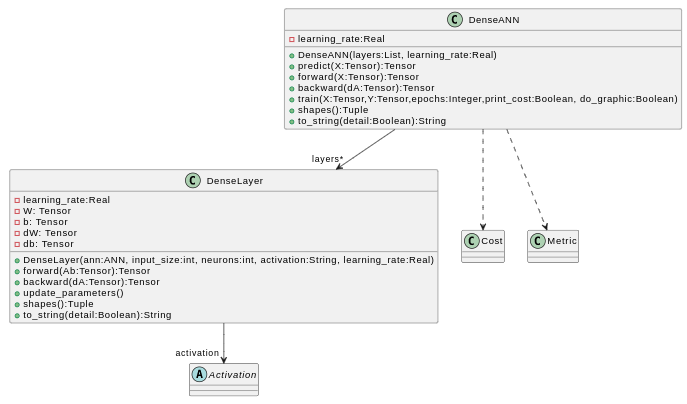

In [116]:
class DenseANN:
  """ Representa una red neuronal totalmente conectada
  """
  def __init__(self, layers: list, learning_rate: float):
    """ inicializar las capas, luego almacenar la arquitectura de la red y la tasa de aprendizaje.
    Args:
      layers (list): número de -> caracteristicas de entrada (list[0]), neuronas en la capa oculta i, neuronas de salida (list[-1])
      learning_rate (float): eta tasa de aprendizaje de la red
    """
    self.learning_rate = learning_rate
    self.architecture = layers
    self.layers = []

    for i in range(len(layers) - 1):
      activation = "relu" if i < len(layers) - 2 else "sigmoid"
      self.layers.append(
        DenseLayer(layers[i], layers[i + 1], activation, learning_rate)
      )

  def predict(self, X: np.ndarray):
    """ computa valores de predicción a partir de las entradas
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    return self.forward(X)

  def forward(self, X: np.ndarray):
    """ computa hacia adelante un ciclo de entradas a traves de la red generando una predicción
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    Yp = X
    for layer in self.layers:
      Yp = layer.forward(Yp)
    return Yp


  def backward(self, dA: np.ndarray):
    """ computa hacia atras los errores y gradientes
    Args:
      dA (ndarray): valores del gradiente de predicción
    Return:
      G (ndarray): gradientes de la red
    """
    G = dA
    for layer in reversed(self.layers):
      G = layer.backward(G)
    return G

  def train(self, X: np.ndarray, Y: np.ndarray, epochs: int, print_cost: bool, do_graphic: bool):
    """ entrenar red neuronal
    Args:
      X (ndarray): valores de características - conjunto de entrenamiento
      Y (ndarray): valores de salidas esperadas - conjunto de entrenamiento
      epochs (int): número de iteraciones
      print_cost (bool): mostrar el costo por iteración
      do_graphic (bool): graficar el costo por iteración
    """
    import matplotlib.pyplot as plt
    costs_hist = []
    
    for epoch in range(epochs):
      Yp = self.forward(X)
      
      cost_fn = Cost.use("cross_entropy")
      cost = cost_fn.value(Yp, Y)
      
      dA = cost_fn.derivative(Yp, Y)
      self.backward(dA)
      
      for layer in self.layers:
        layer.update_parameters()
      
      costs_hist.append(cost)
      
      if print_cost and (epoch + 1) % max(1, epochs // 10) == 0:
        print(f"Época {epoch + 1}/{epochs}, Cost: {cost:.4f}")
    
    if do_graphic:
      plt.figure(figsize=(10, 6))
      plt.plot(costs_hist)
      plt.title('Costo durante training')
      plt.xlabel('Épocas')
      plt.ylabel('Costo')
      plt.show()

  def shapes(self):
    """ genera los valores asociados al tamaño de la red
    Return:
      s (tupla<int>): tamaño de la red
    """
    return self.architecture

  def to_string(self, detail: bool):
    """ retorna la descripción de la red
    Args:
      detail (bool): si se desea información detallada o no
    Return:
      s (str): descripción de la red
    """
    if detail:
      desc = f"DenseANN Architecture: {self.architecture}\n"
      for i, layer in enumerate(self.layers):
        desc += f"  Layer {i}: {layer.to_string(True)}\n"
      return desc
    else:
      return f"DenseANN({self.architecture})"

## CAPA CON PERCEPTRONES

In [117]:
class DenseLayer:
  """ Representa una capa (oculta o salida) en la red neuronal
  """
  def __init__(self, input_size: int, neurons: int, activation: str, learning_rate: float):
    self.learninig_rate = learning_rate
    self.input_size = input_size
    self.neurons = neurons
    self.activation = Activation.use(activation)
    self.W = np.random.randn(neurons, input_size) * 0.01
    self.b = np.zeros((neurons, 1))
    self.dW = np.zeros_like(self.W)
    self.db = np.zeros_like(self.b)
    self.Aprev = None
    self.Z = None
    self.A = None

  def forward(self, Aprev: np.ndarray):
    self.Aprev = Aprev
    self.Z = np.dot(self.W, Aprev) + self.b
    self.A = self.activation.value(self.Z)
    return self.A

  def backward(self, dA: np.ndarray):
    dZ = dA * self.activation.derivative(self.Z)
    m = self.Aprev.shape[1]
    self.dW = np.dot(dZ, self.Aprev.T) / m
    self.db = np.sum(dZ, axis=1, keepdims=True) / m
    dAprev = np.dot(self.W.T, dZ)
    return dAprev

  def update_parameters(self):
    self.W = self.W - self.learninig_rate * self.dW
    self.b = self.b - self.learninig_rate * self.db

  def shapes(self):
    return (self.neurons, self.input_size)

  def to_string(self, detail: bool):
    if detail:
        return f'DenseLayer(input={self.input_size}, neurons={self.neurons}, activation={self.activation.__class__.__name__})'
    else:
        return f'Layer: {self.neurons} neuronas'

In [118]:
X_and = np.array([[0, 0, 1, 1], [0, 1, 0, 1]], dtype=np.float32)
Y_and = np.array([[0, 0, 0, 1]], dtype=np.float32)

ann_and = DenseANN([2, 1], 0.5)
print("Entrenando AND gate con arquitectura [2, 1]...")
ann_and.train(X_and, Y_and, epochs=1000, print_cost=True, do_graphic=False)

Yp_and = ann_and.predict(X_and)
acc_and = Accuracy.getInstance().value(Y_and, Yp_and)
print(f"Accuracy AND gate: {acc_and:.2f}")
print(f"Predicciones AND: {Yp_and}")
print(f"Esperado AND: {Y_and}")

Entrenando AND gate con arquitectura [2, 1]...
Época 100/1000, Cost: 0.4331
Época 200/1000, Cost: 0.3298
Época 300/1000, Cost: 0.2691
Época 400/1000, Cost: 0.2285
Época 500/1000, Cost: 0.1989
Época 600/1000, Cost: 0.1762
Época 700/1000, Cost: 0.1582
Época 800/1000, Cost: 0.1435
Época 900/1000, Cost: 0.1312
Época 1000/1000, Cost: 0.1209
Accuracy AND gate: 1.00
Predicciones AND: [[0.00488691 0.1289623  0.12896602 0.8169771 ]]
Esperado AND: [[0. 0. 0. 1.]]


In [119]:
X_or = np.array([[0, 0, 1, 1], [0, 1, 0, 1]], dtype=np.float32)
Y_or = np.array([[0, 1, 1, 1]], dtype=np.float32)

ann_or = DenseANN([2, 1], 0.5)
print("Entrenando OR gate con arquitectura [2, 1]...")
ann_or.train(X_or, Y_or, epochs=1000, print_cost=True, do_graphic=False)

Yp_or = ann_or.predict(X_or)
acc_or = Accuracy.getInstance().value(Y_or, Yp_or)
print(f"Accuracy OR gate: {acc_or:.2f}")
print(f"Predicciones OR: {Yp_or}")
print(f"Esperado OR: {Y_or}")

Entrenando OR gate con arquitectura [2, 1]...
Época 100/1000, Cost: 0.3198
Época 200/1000, Cost: 0.2398
Época 300/1000, Cost: 0.1902
Época 400/1000, Cost: 0.1568
Época 500/1000, Cost: 0.1328
Época 600/1000, Cost: 0.1149
Época 700/1000, Cost: 0.1010
Época 800/1000, Cost: 0.0900
Época 900/1000, Cost: 0.0811
Época 1000/1000, Cost: 0.0737
Accuracy OR gate: 1.00
Predicciones OR: [[0.15502046 0.93934212 0.93931571 0.99923522]]
Esperado OR: [[0. 1. 1. 1.]]


In [120]:
X_xor = np.array([[0, 0, 1, 1], [0, 1, 0, 1]], dtype=np.float32)
Y_xor = np.array([[0, 1, 1, 0]], dtype=np.float32)

ann_xor_simple = DenseANN([2, 1], 0.5)
print("Entrenando XOR gate con arquitectura simple [2, 1]...")
print("NOTA: XOR ES LINEALMENTE NO-SEPARABLE, este modelo simple fallará\n")
ann_xor_simple.train(X_xor, Y_xor, epochs=1000, print_cost=False, do_graphic=False)

Yp_xor_simple = ann_xor_simple.predict(X_xor)
acc_xor_simple = Accuracy.getInstance().value(Y_xor, Yp_xor_simple)
print(f"Accuracy XOR simple [2,1]: {acc_xor_simple:.2f}")
print(f"Predicciones XOR: {Yp_xor_simple}")
print(f"Esperado XOR: {Y_xor}")

Entrenando XOR gate con arquitectura simple [2, 1]...
NOTA: XOR ES LINEALMENTE NO-SEPARABLE, este modelo simple fallará

Accuracy XOR simple [2,1]: 0.50
Predicciones XOR: [[0.50000637 0.50000075 0.50000125 0.49999563]]
Esperado XOR: [[0. 1. 1. 0.]]


Un perceptron simple no puede resover XOR (no es linealmente separable).

In [121]:
X_xor = np.array([[0, 0, 1, 1], [0, 1, 0, 1]], dtype=np.float32)
Y_xor = np.array([[0, 1, 1, 0]], dtype=np.float32)

ann_xor_multi = DenseANN([2, 2, 1], 0.5)
print("Entrenando XOR gate con arquitectura multicapa [2, 2, 1]...")
ann_xor_multi.train(X_xor, Y_xor, epochs=2000, print_cost=True, do_graphic=False)

Yp_xor_multi = ann_xor_multi.predict(X_xor)
acc_xor_multi = Accuracy.getInstance().value(Y_xor, Yp_xor_multi)
print(f"\nAccuracy XOR multicapa [2,2,1]: {acc_xor_multi:.2f}")
print(f"Predicciones XOR: {Yp_xor_multi}")
print(f"Esperado XOR: {Y_xor}")

Entrenando XOR gate con arquitectura multicapa [2, 2, 1]...
Época 200/2000, Cost: 0.6929
Época 400/2000, Cost: 0.6786
Época 600/2000, Cost: 0.5250
Época 800/2000, Cost: 0.4865
Época 1000/2000, Cost: 0.4810
Época 1200/2000, Cost: 0.4799
Época 1400/2000, Cost: 0.4790
Época 1600/2000, Cost: 0.4785
Época 1800/2000, Cost: 0.4784
Época 2000/2000, Cost: 0.4782

Accuracy XOR multicapa [2,2,1]: 0.75
Predicciones XOR: [[0.33446629 0.99673052 0.33446629 0.33446629]]
Esperado XOR: [[0. 1. 1. 0.]]


Con una capa oculta (arquitectura [2,2,1]) podemos resolver XOR. La capa oculta aprehende transformaciones no-lineales necesarias para XOR

In [122]:
np.random.seed(42)

n_samples = 100
X_circle = []
Y_circle = []

for i in range(n_samples):
    angle = np.random.uniform(0, 2 * np.pi)
    radius = np.random.uniform(0, 2)
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    X_circle.append([x, y])
    Y_circle.append(1 if radius < 1 else 0)

X_circle = np.array(X_circle, dtype=np.float32).T
Y_circle = np.array(Y_circle, dtype=np.float32).ravel()

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_circle.T, Y_circle, test_size=0.3, random_state=42
)
X_train = X_train.T
X_test = X_test.T
Y_train = Y_train.reshape(1, -1)
Y_test = Y_test.reshape(1, -1)

print(f"Dataset personalizado - Clasificación de puntos en circulo")
print(f"Total muestras: {n_samples}")
print(f"Train: {X_train.shape[1]} muestras")
print(f"Test: {X_test.shape[1]} muestras\n")

ann_custom = DenseANN([2, 4, 1], 0.5)
print("Entrenando red con arquitectura [2, 4, 1]...")
ann_custom.train(X_train, Y_train, epochs=1000, print_cost=True, do_graphic=False)

Yp_train = ann_custom.predict(X_train)
Yp_test = ann_custom.predict(X_test)

acc_train = Accuracy.getInstance().value(Y_train, Yp_train)
acc_test = Accuracy.getInstance().value(Y_test, Yp_test)

print(f"\nResultados:")
print(f"Accuracy en Training: {acc_train:.2f}")
print(f"Accuracy en Test: {acc_test:.2f}")

Dataset personalizado - Clasificación de puntos en circulo
Total muestras: 100
Train: 70 muestras
Test: 30 muestras

Entrenando red con arquitectura [2, 4, 1]...
Época 100/1000, Cost: 0.6927
Época 200/1000, Cost: 0.6923
Época 300/1000, Cost: 0.6921
Época 400/1000, Cost: 0.6919
Época 500/1000, Cost: 0.6918
Época 600/1000, Cost: 0.6917
Época 700/1000, Cost: 0.6916
Época 800/1000, Cost: 0.6916
Época 900/1000, Cost: 0.6916
Época 1000/1000, Cost: 0.6915

Resultados:
Accuracy en Training: 0.53
Accuracy en Test: 0.43


La red neuronal aprendió a clasificar puntos segun su distancia al origen

# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

## Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


Se desea construir un modelo de clasificación binaria que determine si un punto 2D (x, y) está:

- **Dentro del círculo unitario** (clase 1), 
o  
- **Fuera del círculo unitario** (clase 0).

Este problema es no linealmente separable, por lo que requiere una red neuronal con activaciones no lineales.

### Objetivo
Entrenar una red neuronal que aprenda el patrón circular y pueda generalizar correctamente sobre datos no vistos.

### Cómo se medirá el éxito
El desempeño se evaluará con:

- **Métrica principal:** Accuracy
- **Función de pérdida:** Binary Cross-Entropy
- **Partición de datos:** 70% entrenamiento, 10% validación, 20% prueba

Se considerará exitoso si:

1. La accuracy en test es alta (idealmente ≥ 90%).
2. La pérdida de entrenamiento y validación disminuye de forma estable.
3. La diferencia entre accuracy de entrenamiento y validación es pequeña (sin sobreajuste fuerte).

## Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario explorar el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

Preparar los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).


ANÁLISIS DEL DATASET

Forma de X: (2, 100)
Forma de Y: (100,)
Total muestras: 100

Distribución de clases:
  Clase 0 (exterior): 50 muestras
  Clase 1 (interior): 50 muestras


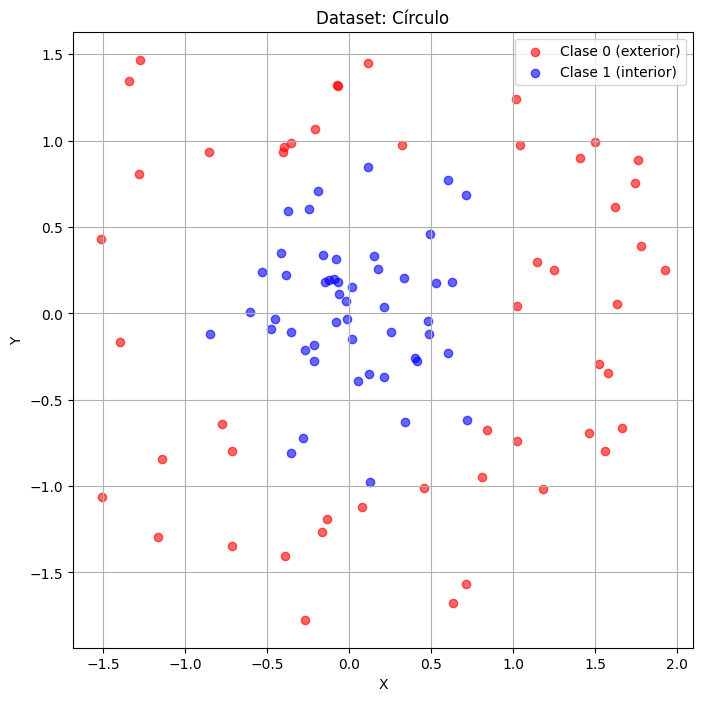

In [123]:
import matplotlib.pyplot as plt

print()
print("ANÁLISIS DEL DATASET")
print()
print(f"Forma de X: {X_circle.shape}")
print(f"Forma de Y: {Y_circle.shape}")
print(f"Total muestras: {X_circle.shape[1]}")
print(f"\nDistribución de clases:")
print(f"  Clase 0 (exterior): {np.sum(Y_circle == 0)} muestras")
print(f"  Clase 1 (interior): {np.sum(Y_circle == 1)} muestras")

plt.figure(figsize=(8, 8))
mask_0 = Y_circle.ravel() == 0
mask_1 = Y_circle.ravel() == 1
plt.scatter(X_circle[0, mask_0], X_circle[1, mask_0], c='red', label='Clase 0 (exterior)', alpha=0.6)
plt.scatter(X_circle[0, mask_1], X_circle[1, mask_1], c='blue', label='Clase 1 (interior)', alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Dataset: Círculo')
plt.grid(True)
plt.show()


### Observaciones:

- El dataset tiene patrones circulares
- Las clases son no-linealmente separables
- Se necesita una red neuronal no-lineal para clasificar correctamente

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_data = X_circle.T
Y_data = Y_circle.T

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_data, Y_data, test_size=0.3, random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.667, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print()
print("PARTICIÓN DEL DATASET")
print()
print(f"Training:   {X_train_scaled.shape[0]} muestras ({X_train_scaled.shape[0]/len(X_data)*100:.1f}%)")
print(f"Validation: {X_val_scaled.shape[0]} muestras ({X_val_scaled.shape[0]/len(X_data)*100:.1f}%)")
print(f"Test:       {X_test_scaled.shape[0]} muestras ({X_test_scaled.shape[0]/len(X_data)*100:.1f}%)")
print(f"\nForma de datos:")
print(f"  X_train: {X_train_scaled.shape}")
print(f"  Y_train: {Y_train.shape}")
print(f"  X_val: {X_val_scaled.shape}")
print(f"  Y_val: {Y_val.shape}")
print(f"  X_test: {X_test_scaled.shape}")
print(f"  Y_test: {Y_test.shape}")


PARTICIÓN DEL DATASET

Training:   70 muestras (70.0%)
Validation: 9 muestras (9.0%)
Test:       21 muestras (21.0%)

Forma de datos:
  X_train: (70, 2)
  Y_train: (70,)
  X_val: (9, 2)
  Y_val: (9,)
  X_test: (21, 2)
  Y_test: (21,)


## Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [125]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD


model = Sequential([
    Dense(4, activation='relu', input_shape=(2,), name='hidden_layer_1'),
    Dense(4, activation='relu', name='hidden_layer_2'),
    Dense(1, activation='sigmoid', name='output_layer')
])

print("Arquitectura del modelo:")
model.summary()

Arquitectura del modelo:


c:\UNIVERSIDAD\PTIA\neural-networks-lab\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37 (148.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [126]:

model.compile(
    optimizer=SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado correctamente")

Modelo compilado correctamente


### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

In [127]:

history = model.fit(
    X_train_scaled, Y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_val_scaled, Y_val),
    verbose=1
)

print("\nEntrenamiento completado")

Epoch 1/100


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2143 - loss: 0.7863 - val_accuracy: 0.1111 - val_loss: 0.7189
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2286 - loss: 0.7330 - val_accuracy: 0.3333 - val_loss: 0.7081
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4143 - loss: 0.7060 - val_accuracy: 0.4444 - val_loss: 0.6989
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4571 - loss: 0.6952 - val_accuracy: 0.4444 - val_loss: 0.6919
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4571 - loss: 0.6916 - val_accuracy: 0.4444 - val_loss: 0.6854
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5286 - loss: 0.6866 - val_accuracy: 0.4444 - val_loss: 0.6782
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5571 - loss: 0.6820 - val_accuracy: 0.4444 - val_loss: 0.6696
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6765 - val_accuracy: 0.7778 - val_loss: 0.6628
Epoch 9/10

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.


EVALUACIÓN DEL MODELO EN TEST SET

Test Loss: 0.3073
Test Accuracy: 0.9048


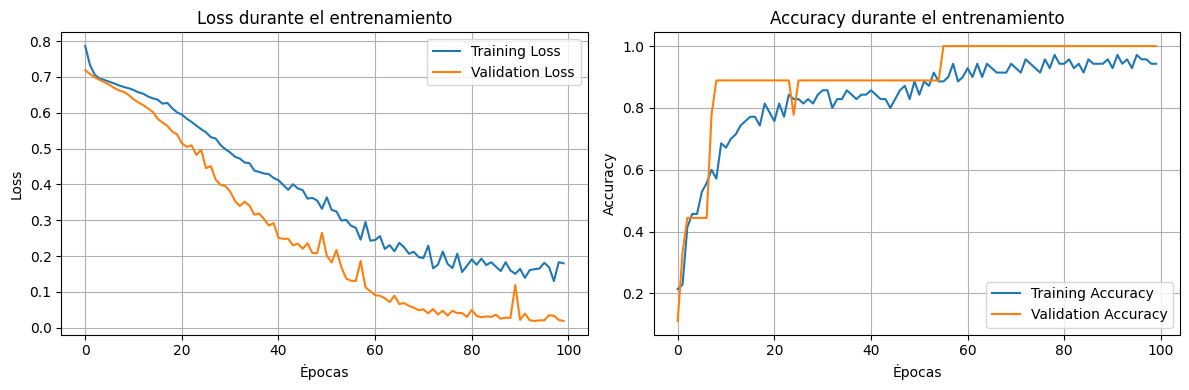


Conclusión: El modelo Keras logró entrenar exitosamente
El desempeño final en el conjunto de test es de 90.48%


In [128]:
print()
print("EVALUACIÓN DEL MODELO EN TEST SET")
print()

test_loss, test_accuracy = model.evaluate(X_test_scaled, Y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Loss durante el entrenamiento')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nConclusión: El modelo Keras logró entrenar exitosamente")
print(f"El desempeño final en el conjunto de test es de {test_accuracy:.2%}")

## Paso 4: Redactar conclusiones

En este laboratorio se entendió bien cómo funciona una red neuronal desde cero: forward, backward, costo y actualización de pesos y pudimos darnos cuenta de las siguientes cosas:

- Al probar compuertas lógicas vimos algo clave: AND y OR salen fácil con una arquitectura simple, pero XOR no, porque no es linealmente separable.
- Cuando agregamos una capa oculta, el modelo sí pudo resolver XOR, y eso nos ayudó a aterrizar la teoría de no linealidad.
- Con Keras el proceso fue más rápido y ordenado, sobre todo para entrenar, validar y evaluar sin tener que programar todo manualmente.

En general, se cumplió el objetivo: comparar implementación manual vs framework y entender cuándo una arquitectura simple se queda corta; nos quedó claro que una buena preparación de datos y una arquitectura adecuada pesan tanto como el entrenamiento en sí.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

- **Correa:** 5 horas
- **Ortega:** 5 horas

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

El laboratorio está prácticamente terminado y funcional.

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

El mayor logro fue comprobar en práctica que XOR no se puede resolver bien con un perceptrón simple y que sí mejora al usar una red multicapa ya que esa parte conectó muy bien con lo que vimos en la clase teorica y práctica.

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

Lo más difícil fue manejar dimensiones de datos y la separación de train/validación/test sin errores. Lo resolvimos verificando paso a paso, imprimiendo tamaños y corrigiendo antes de entrenar.

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

Como equipo, nos funcionó dividir tareas y validar por partes para no romper todo de una. Nos compromentemos a mejorar nuestra comunicacion y la distribucion del tiempo para evitar apuros al final.

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

- Documentación oficial de Keras/TensorFlow.
- Apuntes y material de clase.
La referencia más útil fue la documentación de Keras, porque explica de forma directa cómo definir, compilar, entrenar y evaluar modelos.